# Import the libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

import warnings
warnings.filterwarnings('ignore')

# Create a dataset

In [44]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

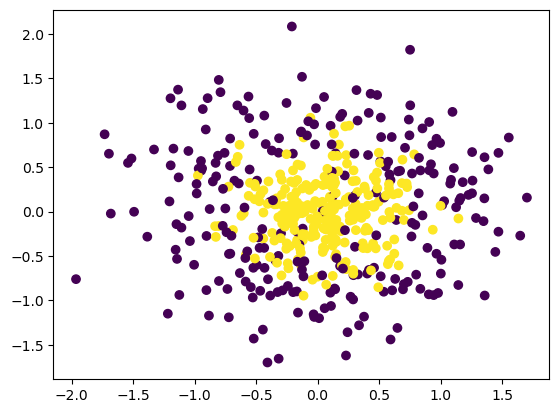

In [45]:
plt.scatter(X[:, 0], X[:, 1], c=y);

# AdaBoost Classifier

In [46]:
def plot_decision_boundary(clf):
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.show()

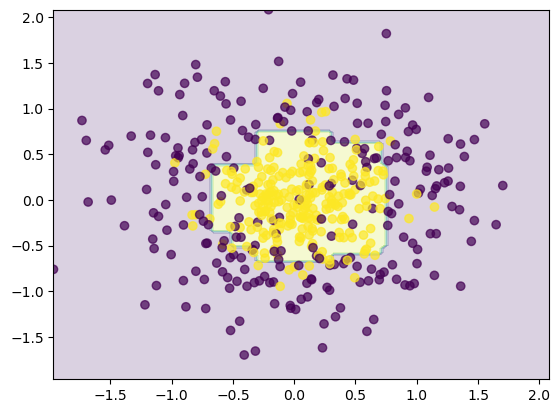

In [53]:
abc = AdaBoostClassifier(n_estimators=1500, learning_rate=0.25)
abc.fit(X, y)
plot_decision_boundary(clf=abc)

## GridSearch CV

In [54]:
param_grid = {
    "n_estimators": [10, 50, 100, 500],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1, 1]
}

In [55]:
gs = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=param_grid, n_jobs=-1, cv=5, scoring='accuracy')

In [56]:
gs.fit(X, y)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.0001, 0.001, 0.01, 0.1, 1],
                         'n_estimators': [10, 50, 100, 500]},
             scoring='accuracy')

In [57]:
print("Best: %f using %s" % (gs.best_score_, gs.best_params_))

Best: 0.834000 using {'learning_rate': 0.1, 'n_estimators': 500}


https://stats.stackexchange.com/questions/82323/shrinkage-parameter-in-adaboost